<a href="https://colab.research.google.com/github/nelsbuhrley/CSE-450-Machine-learning/blob/main/nels_b/module4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Load some test data

import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv")
# data.head(1000)

In [3]:
# data.describe()

In [2]:
#!pip install tensorflow

# Import the libraries we need
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Commonly used modules
import numpy as np

# Images, plots, display, and visualization
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns
# import cv2
# import IPython
# from six.moves import urllib

# print(tf.__version__)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

2026-06-10 11:18:28.323297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# encode time data with sin and cos
data['hour_sin'] = np.sin(data['hr']*(2.*np.pi/24))
data['hour_cos'] = np.cos(data['hr']*(2.*np.pi/24))

# encode seasons cyclically store as 8 bit intigers
data['season_sin'] = np.sin(data['season']*(2.*np.pi/4))
data['season_cos'] = np.cos(data['season']*(2.*np.pi/4))

# take the dteday and encode it as a numerice day, month, year column
data['dteday'] = pd.to_datetime(data['dteday'])
data['day'] = data['dteday'].dt.day
data['month'] = data['dteday'].dt.month
data['year'] = data['dteday'].dt.year

# encode all the hours sequencially starting with hour 1 @ midnight 1/1/2000
ref_date = pd.Timestamp('2000-01-01')
data['total_hours'] = (data['dteday'] - ref_date).dt.total_seconds() / 3600 + data['hr']

# cyclical representation of the total hours
data['time_sin'] = np.sin(data['total_hours'] * (2. * np.pi / 24))
data['time_cos'] = np.cos(data['total_hours'] * (2. * np.pi / 24))

# normalise the data
num_cols = ['temp_c', 'feels_like_c', 'hum', 'windspeed', 'total_hours','weathersit']
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

val = 2
## create a weather intensity column
data['weather_intensity'] = ((data['temp_c']**val + data['hum']**val + data['windspeed']**val + data['weathersit']**val)/3)**(1/val)

# Fixed typo 'regestered' -> 'registered' and added errors='ignore' to prevent KeyError on re-runs
drop_cols = ['dteday', 'hr','casual', 'registered']


# display(data.drop(columns=[c for c in drop_cols if c in data.columns]).head(1000))

In [4]:
y = data[['casual', 'registered']]
x = data.drop(columns=['dteday','hr','casual','registered'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

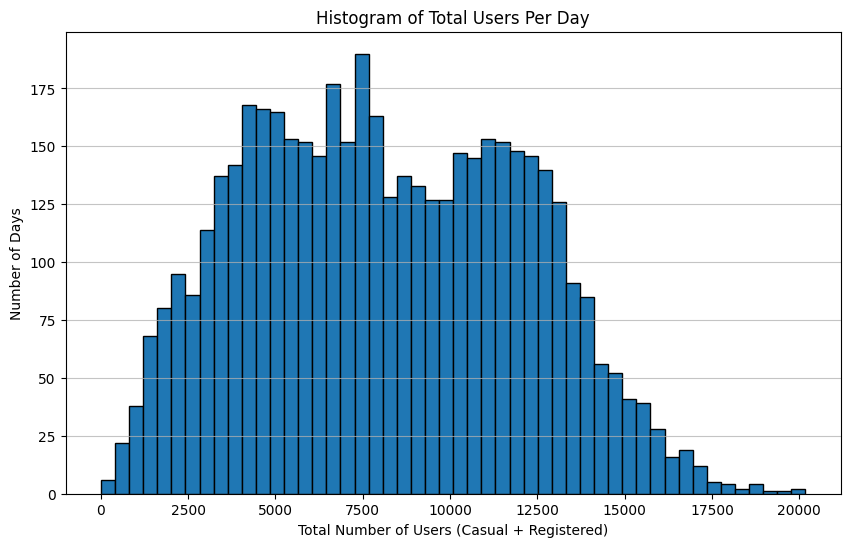

In [6]:
daily_users = data.groupby('dteday')[['casual', 'registered']].sum().reset_index()
daily_users['total_users'] = daily_users['casual'] + daily_users['registered']

plt.figure(figsize=(10, 6))
plt.hist(daily_users['total_users'], bins=50, edgecolor='black')
plt.title('Histogram of Total Users Per Day')
plt.xlabel('Total Number of Users (Casual + Registered)')
plt.ylabel('Number of Days')
plt.grid(axis='y', alpha=0.75)
plt.show()

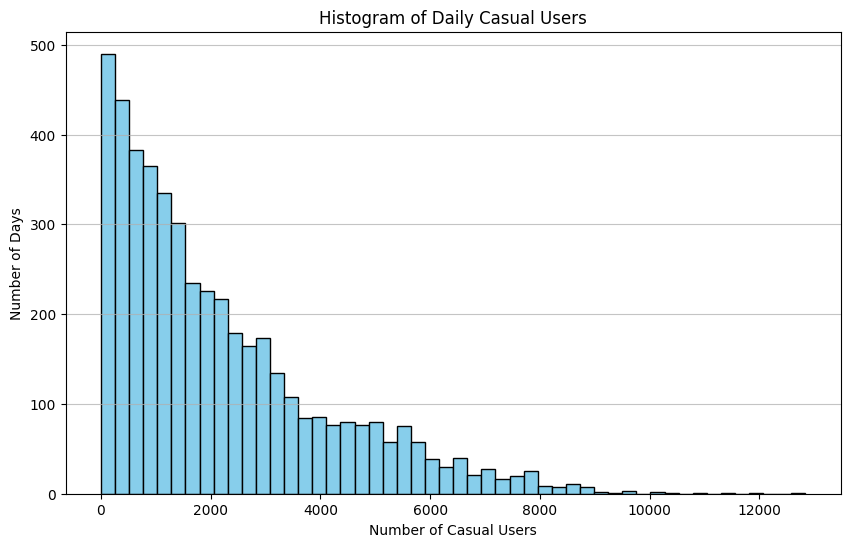

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(daily_users['casual'], bins=50, edgecolor='black', color='skyblue')
plt.title('Histogram of Daily Casual Users')
plt.xlabel('Number of Casual Users')
plt.ylabel('Number of Days')
plt.grid(axis='y', alpha=0.75)
plt.show()

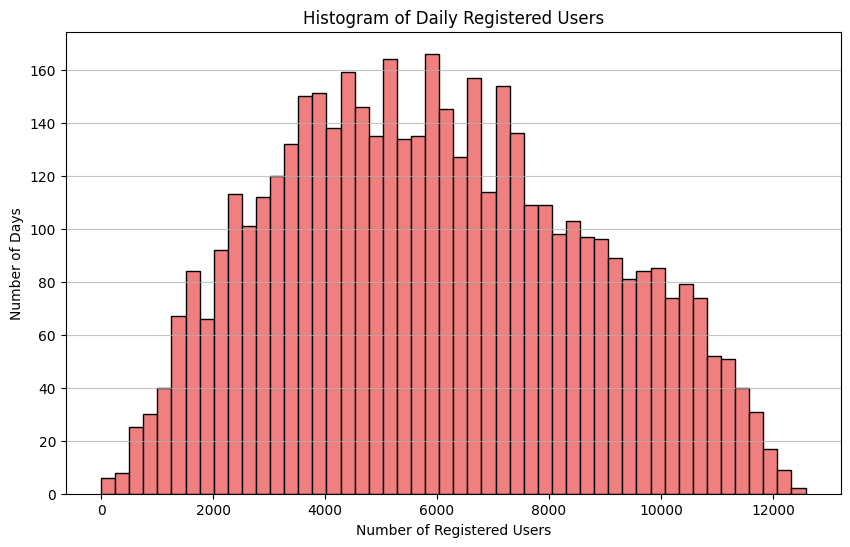

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(daily_users['registered'], bins=50, edgecolor='black', color='lightcoral')
plt.title('Histogram of Daily Registered Users')
plt.xlabel('Number of Registered Users')
plt.ylabel('Number of Days')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [9]:
from sklearn.preprocessing import MinMaxScaler

# fit scaler on training data
norm = MinMaxScaler().fit(X_train)

# transform training data
X_train = norm.transform(X_train)

# transform testing dataabs
X_test = norm.transform(X_test)

In [ ]:
# len(X_train[0])

In [10]:
model = Sequential()
model.add(Dense(128, input_dim=len(X_train[0]), activation='relu'))
model.add(Dropout(.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(.2))
model.add(Dense(64, activation='leaky_relu'))

model.add(Dense(2, activation='relu'))

/Users/nelsbuhrley/development/CSE-450-Machine-learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,162 (203.76 KB)

 Trainable params: 52,162 (203.76 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# opt = keras.optimizers.Adam(learning_rate=0.0001)
opt = keras.optimizers.Adam()
model.compile(loss="mean_squared_error", optimizer=opt, metrics=['mse'])

In [13]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_mse', patience=10)

history = model.fit(X_train, y_train, epochs=1000, validation_split=.35, batch_size=100, callbacks=[early_stop],shuffle=False)
# history = model.fit(train_features, train_labels, epochs=2000, verbose=0, validation_split = .2, batch_size=tester2,
#                     callbacks=[early_stop, PrintDot()])

hist = pd.DataFrame(history.history)

Epoch 1/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31509.8535 - mse: 31509.8535 - val_loss: 21888.5898 - val_mse: 21888.5898
Epoch 2/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20652.4980 - mse: 20652.4980 - val_loss: 16782.2266 - val_mse: 16782.2266
Epoch 3/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17750.1660 - mse: 17750.1660 - val_loss: 13688.5117 - val_mse: 13688.5117
Epoch 4/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15332.1689 - mse: 15332.1689 - val_loss: 11757.9873 - val_mse: 11757.9873
Epoch 5/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13716.8691 - mse: 13716.8691 - val_loss: 10224.0264 - val_mse: 10224.0264
Epoch 6/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12614.2764 - mse: 12614.2754 - val_loss: 9133.1133 - val_mse: 9133.1133
Epoch 7/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11692.7998 - mse: 11692.7998 - val_loss: 8509.0664 - val_mse: 8509.0674
Epoch 8/1000
512/512 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

KeyboardInterrupt: 

In [14]:
# h = hist
hist = hist.reset_index()
# h

NameError: name 'hist' is not defined

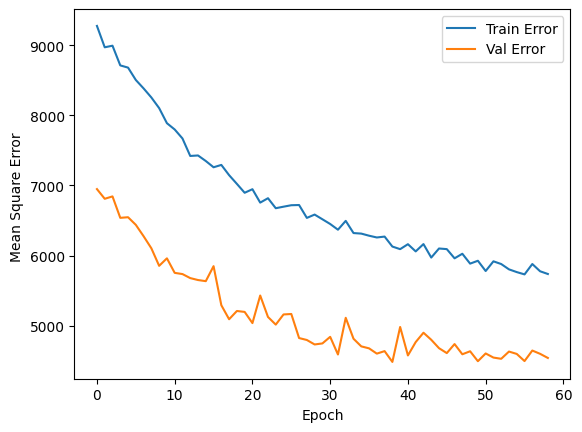

In [ ]:
def plot_history():
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error ')
    plt.plot(hist['index'], hist['mse'], label='Train Error')
    plt.plot(hist['index'], hist['val_mse'], label = 'Val Error')
    plt.legend()
    # plt.ylim([0,50])

plot_history()

In [ ]:
predictions = np.round(model.predict(X_test),1)

1055/1055 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step


In [ ]:

result = root_mean_squared_error(y_test, predictions)
result

67.3290023803711

In [ ]:
r2 = r2_score(y_test,predictions)

Epoch 1/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0096 - mae: 0.0689 - mse: 0.0234 - val_loss: 0.0033 - val_mae: 0.0503 - val_mse: 0.0066 - learning_rate: 0.0100
Epoch 2/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0018 - mae: 0.0387 - mse: 0.0036 - val_loss: 0.0012 - val_mae: 0.0304 - val_mse: 0.0023 - learning_rate: 0.0100
Epoch 3/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0015 - mae: 0.0349 - mse: 0.0031 - val_loss: 0.0013 - val_mae: 0.0313 - val_mse: 0.0025 - learning_rate: 0.0100
Epoch 4/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0015 - mae: 0.0343 - mse: 0.0029 - val_loss: 0.0014 - val_mae: 0.0394 - val_mse: 0.0028 - learning_rate: 0.0100
Epoch 5/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0014 - mae: 0.0337 - mse: 0.0028 - val_loss: 9.5839e-04 - val_mae: 0.0284 - val_mse: 0.0019 - learning_rate: 0.0100
Epoch 6/1000
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0014 - mae: 0.0341 - mse: 0.0029 - val_loss: 0

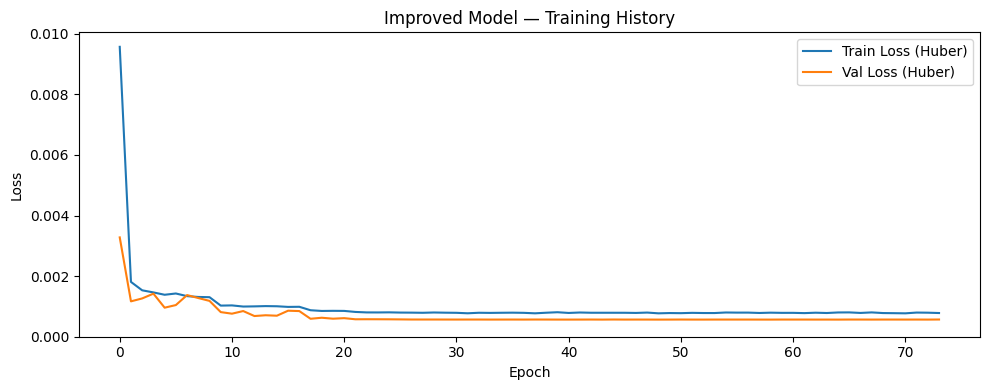

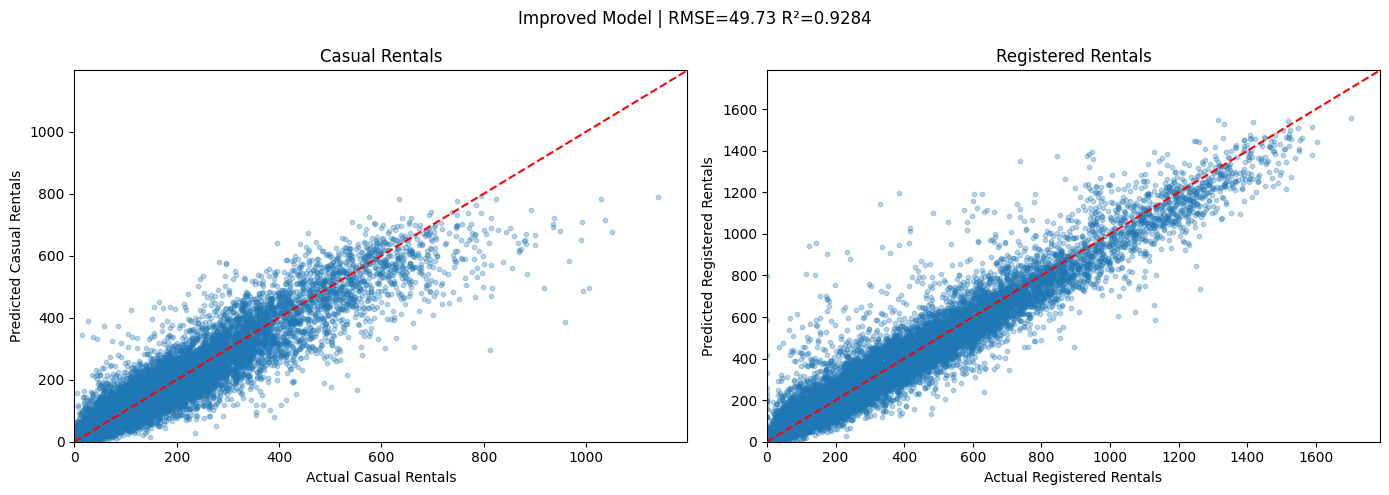

In [15]:
# ============================================================
# IMPROVED MODEL V2
# Key changes:
#  1. Robust Loss: Switched to Huber loss (robust to outliers)
#  2. Architecture: Deeper layers with 'swish' activation
#  3. Callbacks: Increased EarlyStopping patience to 50
#  4. Scaling: Keeping the target scaling (MinMax) which is essential
# ============================================================

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

# --- Scale the target variable ---
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled  = y_scaler.transform(y_test)

# --- Build improved model ---
n_features = X_train.shape[1]

improved_model = Sequential([
  Input(shape=(n_features,)),

  Dense(512, activation='swish'),
  BatchNormalization(),
  Dropout(0.2),

  Dense(256, activation='swish'),
  BatchNormalization(),
  Dropout(0.2),

  Dense(128, activation='swish'),
  BatchNormalization(),

  Dense(64, activation='swish'),
  Dense(2, activation='linear')
])

# --- Compile with Huber loss for robustness ---
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
improved_model.compile(
  loss=tf.keras.losses.Huber(),
  optimizer=opt,
  metrics=['mae', 'mse']
)

# --- Callbacks ---
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=25, # More patience to allow for complex convergence
  restore_best_weights=True,
  verbose=1
)

reduce_lr = ReduceLROnPlateau(
  monitor='val_loss',
  factor=0.2,
  patience=4,
  min_lr=1e-6,
  verbose=1
)

# --- Train ---
history2 = improved_model.fit(
  X_train, y_train_scaled,
  epochs=1000, # Higher epoch limit, EarlyStopping handles the rest
  batch_size=128,
  validation_split=0.2,
  callbacks=[early_stop, reduce_lr],
  shuffle=True,
  verbose=1
)

# --- Evaluate ---
pred_scaled = improved_model.predict(X_test)
pred_orig   = y_scaler.inverse_transform(pred_scaled)
pred_orig   = np.clip(np.round(pred_orig, 1), 0, None)
rmse_improved = root_mean_squared_error(y_test, pred_orig)
r2_improved   = r2_score(y_test, pred_orig)

print(f"\n--- Improved Model Results ---")
print(f"RMSE : {rmse_improved:.4f}")
print(f"R²   : {r2_improved:.4f}")

# --- Plot training curves ---
hist2 = pd.DataFrame(history2.history).reset_index()
plt.figure(figsize=(10, 4))
plt.plot(hist2['index'], hist2['loss'], label='Train Loss (Huber)')
plt.plot(hist2['index'], hist2['val_loss'], label='Val Loss (Huber)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Improved Model — Training History')
plt.ylim(0, max(hist2['loss'].max(), hist2['val_loss'].max()) * 1.05) # Added y-axis limit
plt.legend(); plt.tight_layout(); plt.show()

# --- Actual vs Predicted scatter ---
pred_df = pd.DataFrame(pred_orig, columns=['pred_casual', 'pred_registered'])
pred_df['actual_casual']     = y_test['casual'].reset_index(drop=True)
pred_df['actual_registered'] = y_test['registered'].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, actual_col, pred_col, title in zip(
    axes,
    ['actual_casual', 'actual_registered'],
    ['pred_casual', 'pred_registered'],
    ['Casual Rentals', 'Registered Rentals']
):
    mx = max(pred_df[actual_col].max(), pred_df[pred_col].max()) * 1.05
    ax.scatter(pred_df[actual_col], pred_df[pred_col], alpha=0.3, s=10)
    ax.plot([0, mx], [0, mx], 'r--')
    ax.set_xlabel(f'Actual {title}'); ax.set_ylabel(f'Predicted {title}')
    ax.set_title(title); ax.set_xlim(0, mx); ax.set_ylim(0, mx)

plt.suptitle(f'Improved Model | RMSE={rmse_improved:.2f} R²={r2_improved:.4f}')
plt.tight_layout(); plt.show()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corrected creation of the DataFrame `pred` with appropriate column names
# 'predictions' array has 2 columns (for casual and registered), so we provide two column names.
pred = pd.DataFrame(predictions, columns=['predicted_casual', 'predicted_registered'])

# Add the actual 'casual' and 'registered' values from y_test as separate columns.
# .reset_index(drop=True) is used to ensure index alignment during assignment.
pred['actual_casual'] = y_test['casual'].reset_index(drop=True)
pred['actual_registered'] = y_test['registered'].reset_index(drop=True)

# Calculate the differences for both casual and registered
pred['difference_casual'] = pred['actual_casual'] - pred['predicted_casual']
pred['difference_registered'] = pred['actual_registered'] - pred['predicted_registered']

# Display the head of the combined DataFrame to see the new structure
print(pred.head())

# Since we now have two target variables (casual, registered), we will visualize both.
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Create two subplots

# Plot for 'casual' rentals
# Determine x and y limits dynamically for better visualization
max_val_casual = max(pred['actual_casual'].max(), pred['predicted_casual'].max())
xlims_casual = (0, max_val_casual * 1.1) if max_val_casual > 0 else (0, 1) # Ensure non-zero limit if all values are 0

sns.scatterplot(data=pred, x='actual_casual', y='predicted_casual', ax=axes[0])
axes[0].set_title('Casual Rentals: Actual vs Predicted')
axes[0].plot(xlims_casual, xlims_casual, color='r', linestyle='--') # Add diagonal line
axes[0].set_xlabel('Actual Casual')
axes[0].set_ylabel('Predicted Casual')
axes[0].set_xlim(xlims_casual)
axes[0].set_ylim(xlims_casual)

# Plot for 'registered' rentals
# Determine x and y limits dynamically
max_val_registered = max(pred['actual_registered'].max(), pred['predicted_registered'].max())
xlims_registered = (0, max_val_registered * 1.1) if max_val_registered > 0 else (0, 1)

sns.scatterplot(data=pred, x='actual_registered', y='predicted_registered', ax=axes[1])
axes[1].set_title('Registered Rentals: Actual vs Predicted')
axes[1].plot(xlims_registered, xlims_registered, color='r', linestyle='--') # Add diagonal line
axes[1].set_xlabel('Actual Registered')
axes[1].set_ylabel('Predicted Registered')
axes[1].set_xlim(xlims_registered)
axes[1].set_ylim(xlims_registered)

plt.tight_layout() # Adjust layout to prevent subplot overlap
plt.show()

ModuleNotFoundError: No module named 'seaborn'